# Heart Disease — Exploratory Data Analysis

Dataset: **UCI Heart Disease (Cleveland)** — 14 attributes, binary target `target` (0 = no disease, 1 = disease).

Outputs from this notebook (plots) are saved under `reports/figures/` and referenced by the final report.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RAW_CSV, FIGURE_DIR, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    TARGET_COLUMN, TARGET_LABELS,
)
from src.data.download import download

sns.set_theme(style='whitegrid', context='notebook')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data

In [2]:
if not RAW_CSV.exists():
    download()

df = pd.read_csv(RAW_CSV)
print('Shape :', df.shape)
print('Cols  :', list(df.columns))
df.head()

Shape : (297, 14)
Cols  : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,63.0,145.0,233.0,150.0,2.3,1.0,1.0,1.0,2.0,0.0,3.0,0.0,6.0,0
1,67.0,160.0,286.0,108.0,1.5,1.0,4.0,0.0,2.0,1.0,2.0,3.0,3.0,1
2,67.0,120.0,229.0,129.0,2.6,1.0,4.0,0.0,2.0,1.0,2.0,2.0,7.0,1
3,37.0,130.0,250.0,187.0,3.5,1.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0
4,41.0,130.0,204.0,172.0,1.4,0.0,2.0,0.0,2.0,0.0,1.0,0.0,3.0,0


In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   trestbps  297 non-null    float64
 2   chol      297 non-null    float64
 3   thalach   297 non-null    float64
 4   oldpeak   297 non-null    float64
 5   sex       297 non-null    float64
 6   cp        297 non-null    float64
 7   fbs       297 non-null    float64
 8   restecg   297 non-null    float64
 9   exang     297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.158249,0.964859,1.0,3.0,3.0,4.0,4.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0


## 2. Missing values & class balance

**Gap-1 evidence — raw missing values *before* cleaning.**
The cleaned `data/raw/heart_disease.csv` already has zero NAs, so we re-read the
canonical UCI file `processed.cleveland.data` with `na_values='?'` to show that
the `?` markers in `ca` and `thal` were correctly handled by `download.py::_clean()`.

In [4]:
from src.data.download import LOCAL_CLEVELAND_PATH, COLUMN_NAMES

raw = pd.read_csv(LOCAL_CLEVELAND_PATH, header=None,
                  names=COLUMN_NAMES, na_values='?')
raw_missing = raw.isna().sum()
raw_missing = raw_missing[raw_missing > 0]
print(f'Raw rows : {len(raw)}')
print(f'Cleaned  : {len(df)}  (dropped {len(raw) - len(df)} rows with NA)')
print('\nMissing values per column (raw, before cleaning):')
print(raw_missing.to_string() if len(raw_missing) else '  (none)')

Raw rows : 303
Cleaned  : 297  (dropped 6 rows with NA)

Missing values per column (raw, before cleaning):
ca      4
thal    2


Missing values per column:
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
sex         0
cp          0
fbs         0
restecg     0
exang       0
slope       0
ca          0
thal        0
target      0
dtype: int64


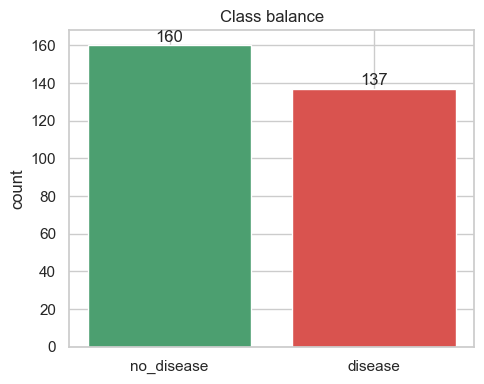

In [5]:
print('Missing values per column:')
print(df.isna().sum())

fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET_COLUMN].value_counts().sort_index()
labels = [TARGET_LABELS[i] for i in counts.index]
ax.bar(labels, counts.values, color=['#4C9F70', '#D9534F'])
ax.set_title('Class balance')
ax.set_ylabel('count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha='center')
plt.tight_layout(); plt.savefig(FIGURE_DIR / 'class_balance.png', dpi=120); plt.show()

## 3. Numeric distributions

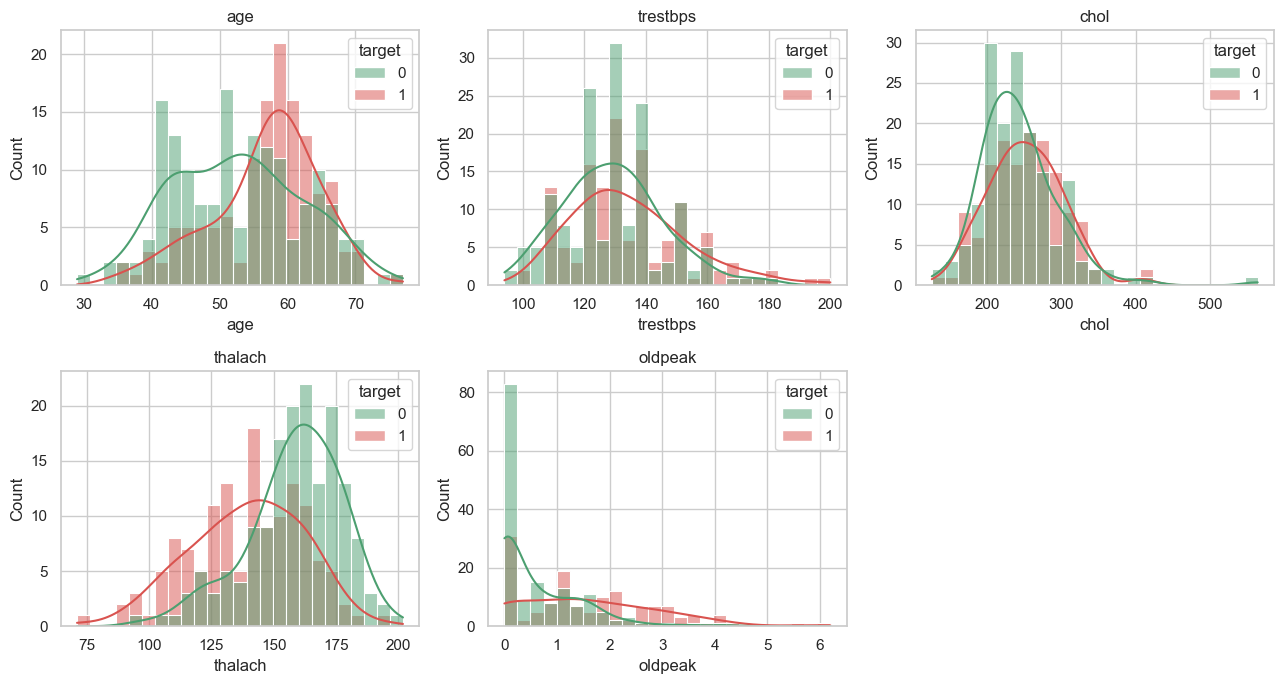

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue=TARGET_COLUMN, bins=25, kde=True,
                 palette={0: '#4C9F70', 1: '#D9534F'}, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig(FIGURE_DIR / 'numeric_distributions.png', dpi=120); plt.show()

## 3b. Per-class boxplots (numeric features)

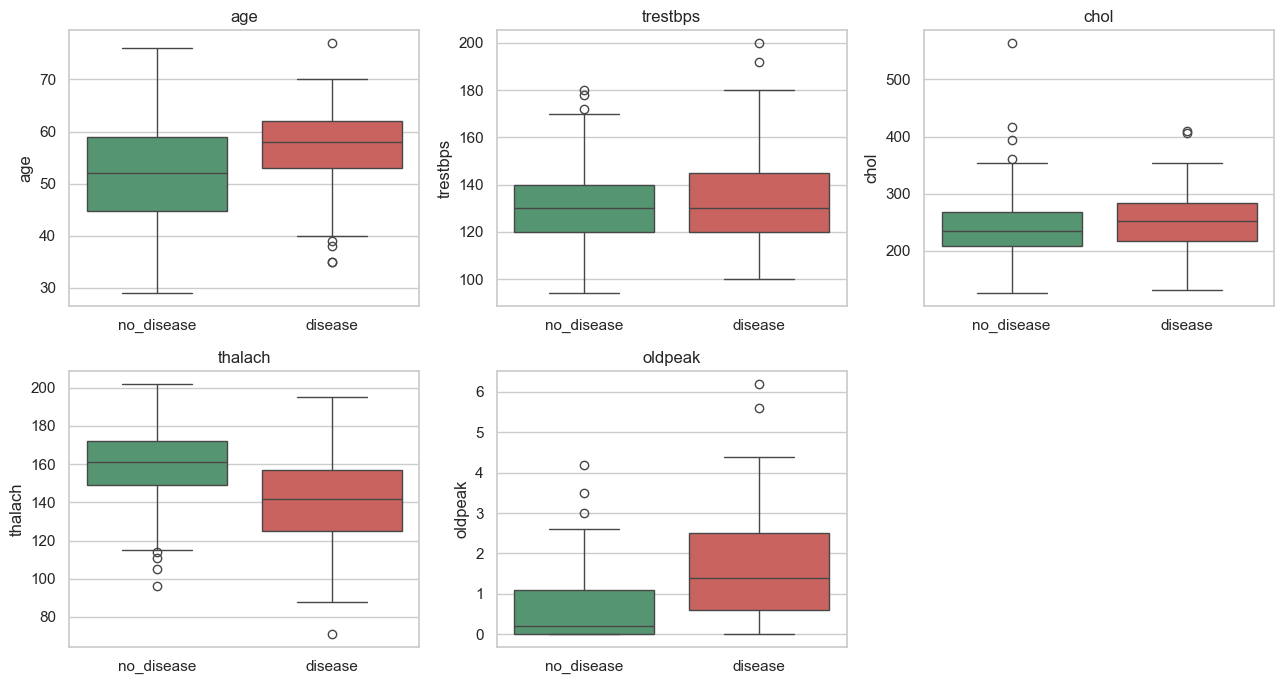

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col,
                hue=TARGET_COLUMN, legend=False,
                palette={0: '#4C9F70', 1: '#D9534F'}, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([TARGET_LABELS[0], TARGET_LABELS[1]])
    ax.set_xlabel(''); ax.set_title(col)
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig(FIGURE_DIR / 'numeric_boxplots.png', dpi=120); plt.show()

## 4. Categorical features vs target

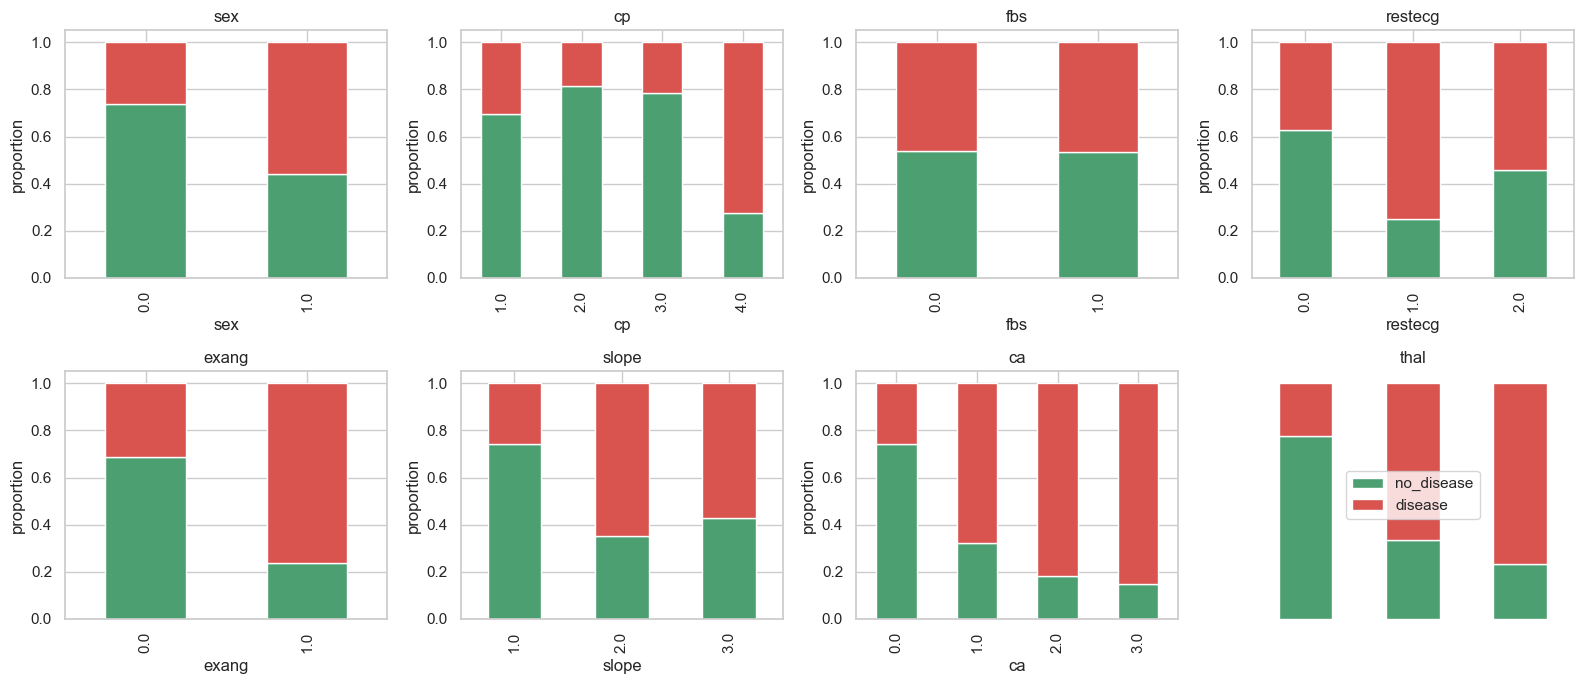

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    ct = pd.crosstab(df[col], df[TARGET_COLUMN], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4C9F70', '#D9534F'], legend=False)
    ax.set_title(col); ax.set_ylabel('proportion')
axes.flat[-1].legend(['no_disease', 'disease'], loc='center')
axes.flat[-1].axis('off')
plt.tight_layout(); plt.savefig(FIGURE_DIR / 'categorical_vs_target.png', dpi=120); plt.show()

## 5. Correlation heatmap

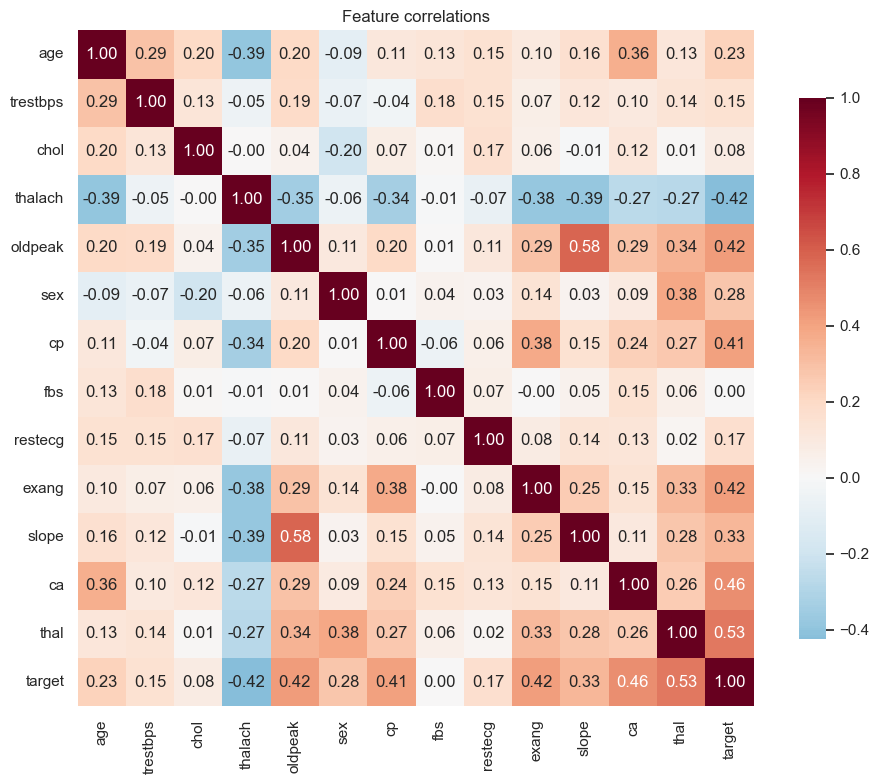

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Feature correlations')
plt.tight_layout(); plt.savefig(FIGURE_DIR / 'correlation_heatmap.png', dpi=120); plt.show()

## 5b. Feature association with target (ranked |corr|)

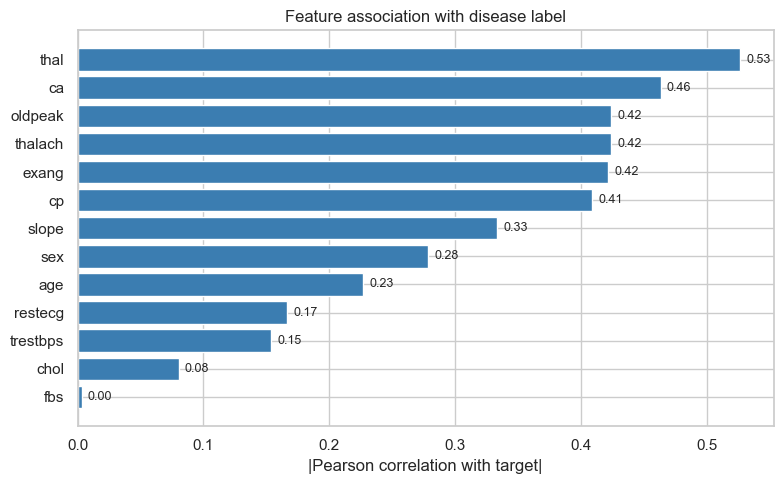


Top 5 features by |corr| with target:
thal       0.527
ca         0.463
oldpeak    0.424
thalach    0.424
exang      0.421


In [10]:
target_corr = (df.corr(numeric_only=True)[TARGET_COLUMN]
                 .drop(TARGET_COLUMN)
                 .abs()
                 .sort_values())
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(target_corr.index, target_corr.values, color='#3B7DB1')
ax.set_xlabel('|Pearson correlation with target|')
ax.set_title('Feature association with disease label')
for i, v in enumerate(target_corr.values):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'target_correlation_ranked.png', dpi=120); plt.show()
print('\nTop 5 features by |corr| with target:')
print(target_corr.sort_values(ascending=False).head(5).round(3).to_string())

## 6. Key takeaways

* The target is **mildly imbalanced** (~46% positives) — accuracy alone is misleading; we report ROC-AUC, precision and recall.
* `cp` (chest-pain type), `thalach` (max heart rate) and `oldpeak` show strong association with the target.
* Some features (`ca`, `thal`) had a few `?` values in the raw UCI file — handled by `download.py` (rows dropped).
* Mixed numeric + categorical types motivate a `ColumnTransformer` (StandardScaler + OneHotEncoder).
* **Outliers:** `chol` has a small number of values >400 (max ~564) and `trestbps` has a few >180 — kept in the dataset since they are physiologically plausible and tree-based models handle them gracefully; `StandardScaler` reduces their leverage on the linear model. The boxplots in section 3b make these points visible per class.